In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models import logreg

# The Dataset
## Reading it in
This dataset comes from [The Breast Cancer Dataset on Kaggle](https://www.kaggle.com/datasets/imtkaggleteam/breast-cancer) from the University of Wisconsin. The data contains diagnostic information as well as the diagnosis.

In [2]:
df = pd.read_csv(r'./breast-cancer-wisconsin-data_data.csv')
df = df.drop(columns=['Unnamed: 32'])
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Dataset Description
The dataset has 32 columns, one of which is an identifier, another a diagnosis. The rest are diagnostic criteria for breast cancer. Just perusing the data, we notice that the data is not on the same scale. We will normalize the scales of all features to be between 0 and 1 to prevent a model from over-learning on a high valued feature.

In [4]:
shuffled_idxs = np.array(df['id'])
np.random.shuffle(shuffled_idxs)
split_point1 = int(.7*len(shuffled_idxs))
split_point2 = int(.9*len(shuffled_idxs))
idxs_train = shuffled_idxs[:split_point1]
idxs_val = shuffled_idxs[split_point1:split_point2]
idxs_test = shuffled_idxs[split_point2:]

In [5]:
all_train = df[df['id'].isin(idxs_train)]
all_val = df[df['id'].isin(idxs_val)]
all_test = df[df['id'].isin(idxs_test)]
x_train = all_train.drop(columns=['id', 'diagnosis']).to_numpy()
x_val = all_val.drop(columns=['id', 'diagnosis']).to_numpy()
x_test = all_test.drop(columns=['id', 'diagnosis']).to_numpy()


In [6]:
def scale_cols(x):
    # TODO: MAKE MORE ROBUST CAUSE V FRAGILE AS IS
    return (x - min(x)) / (max(x) - min(x))
x_train_scaled = np.apply_along_axis(scale_cols, 0, x_train)
biases = np.ones((x_train_scaled.shape[0], 1))
x_train_scaled = np.hstack([biases, x_train_scaled])
x_val_scaled = np.apply_along_axis(scale_cols, 0, x_val)
biases = np.ones((x_val_scaled.shape[0], 1))
x_val_scaled = np.hstack([biases, x_val_scaled])
x_test_scaled = np.apply_along_axis(scale_cols, 0, x_test)
biases = np.ones((x_test_scaled.shape[0], 1))
x_test_scaled = np.hstack([biases, x_test_scaled])

In [7]:
# M indicates malignant tumor. We will use represent this as 1 for "cancer present"
y_train = all_train['diagnosis']
y_val = all_val['diagnosis']
y_test = all_test['diagnosis']
ys_train = np.zeros(len(y_train))
ys_train[y_train == 'M'] = 1
ys_val = np.zeros(len(y_val))
ys_val[y_val == 'M'] = 1
ys_test = np.zeros(len(y_test))
ys_test[y_test == 'M'] = 1


In [8]:
# Seeing if dataset is balanced
print(ys_train.sum()/len(ys_train), 212/569)
# Note to self, may be unbalanced. Check if that causes problems later

0.3793969849246231 0.37258347978910367


# Machine Learning Model Comparison
## Logistic regression
`cls` is my model implemented from scratch. Let's investigate it! We will do a learning rate of 0.001 and regularization parameter of 0.1

In [9]:
cls = logreg()
cls.fit(x_train_scaled, ys_train, x_val_scaled, ys_val)
losses, val_losses = cls.train(reg_param = 0.1)

Trained in 2526507 Epochs. 
 Validation Accuracy: 94.73684210526316%


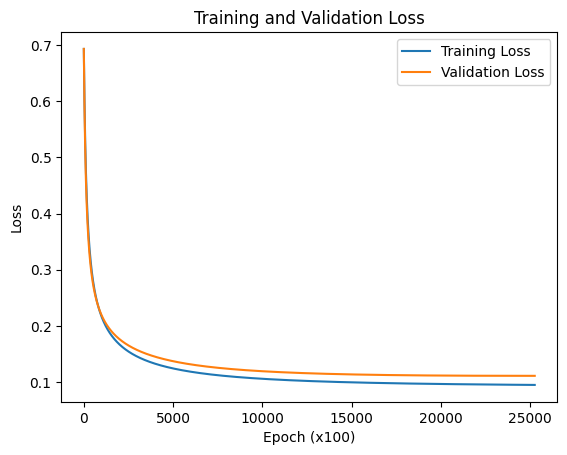

In [10]:
fig, ax = plt.subplots()
ax.plot(losses, label="Training Loss")
ax.plot(val_losses, label="Validation Loss")
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch (x100)')
ax.set_ylabel('Loss')
ax.legend()

In [11]:
# Testing on test data
predicted = cls.predict(x_test_scaled)
ys_test_arr = ys_test[:, np.newaxis]
diffs = abs(ys_test_arr - predicted)
errors_percent = np.sum(diffs)/len(ys_test_arr)*100
print(f'Test error is {errors_percent}%')

Test error is 5.263157894736842%


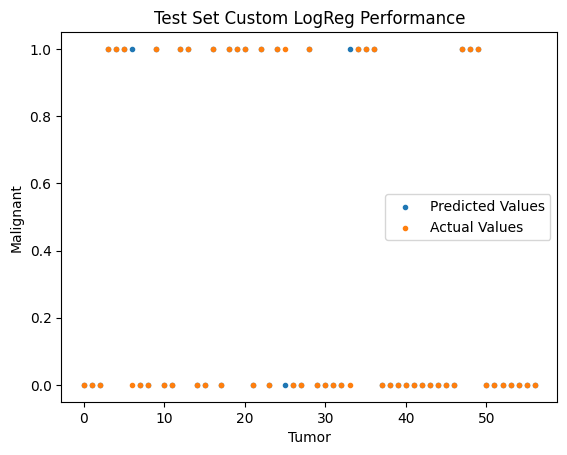

In [12]:
fig, ax = plt.subplots()
ax.scatter(x=range(len(predicted)), y=predicted, marker='.', label="Predicted Values")
ax.scatter(x=range(len(ys_test)), y=ys_test, marker='.', label="Actual Values")
ax.set_title('Test Set Custom LogReg Performance')
ax.set_xlabel('Tumor')
ax.set_ylabel('Malignant')
ax.legend()

### Initial Results
It appears the model is generalizing well, as demonstrated by the test error

### Hyperparameter Selection
We picked some reasonable hyperparameters to start, but let's see if there are any better ones. We will be selecting for highest accuracy on the validation set. An increase in learning rate in general may lead to faster training, but it may also lead to minimums being missed and if trained too long at too high a learning rate, there is risk of the loss exploding. Training with a smaller learning rate will make us more likely to not miss the optimal weights that create the lowest loss, but we may also never converge in our time allowed. The regularization parameter will help balance the bias/variance tradeoff. Too high, and our model will have high bias and not enough variance to give meaningful results based on the data. Too low, and the model will be overfit on the training set and not have enough bias to be generalized. We will select from a combination of the following parameters: `[10, 1, 0, 0.1, 0.1, 0.001, 0.0001, and 0.00001]`. We will not investigate a learning rate of 0 as this does not give us a meaningful result. In the event of a tie, we choose the lowest validation loss. 

In [13]:
optim, best_accuracy, loss_by_param = cls.hypertune(detailed_output=True)

Checking learning rate=10 and regularization parameter=10
Trained in 23 Epochs. 
 Validation Accuracy: 49.122807017543856%
Checking learning rate=10 and regularization parameter=1
Trained in 46 Epochs. 
 Validation Accuracy: 94.73684210526316%
Checking learning rate=10 and regularization parameter=0
Trained in 271 Epochs. 
 Validation Accuracy: 92.98245614035088%
Checking learning rate=10 and regularization parameter=0.1
Trained in 313 Epochs. 
 Validation Accuracy: 93.85964912280701%
Checking learning rate=10 and regularization parameter=0.01
Trained in 279 Epochs. 
 Validation Accuracy: 92.98245614035088%
Checking learning rate=10 and regularization parameter=0.001
Trained in 272 Epochs. 
 Validation Accuracy: 92.98245614035088%
Checking learning rate=10 and regularization parameter=0.0001
Trained in 271 Epochs. 
 Validation Accuracy: 92.98245614035088%
Checking learning rate=10 and regularization parameter=1e-05
Trained in 271 Epochs. 
 Validation Accuracy: 92.98245614035088%
Checki

In [14]:
best_accuracy

np.float64(0.9649122807017544)

Test error is 5.263157894736842%


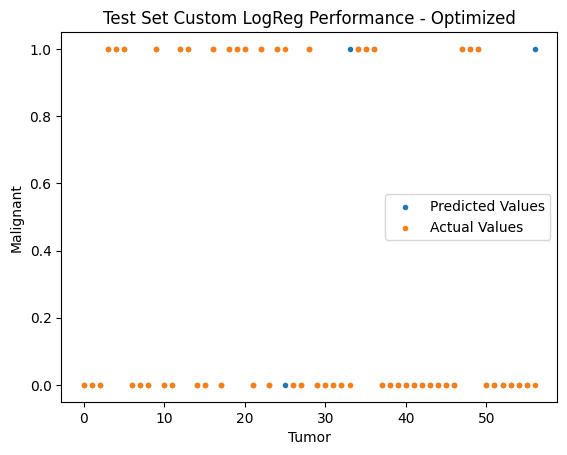

In [15]:
# Testing on test data
predicted = cls.predict(x_test_scaled)
ys_test_arr = ys_test[:, np.newaxis]
diffs = abs(ys_test_arr - predicted)
errors_percent = np.sum(diffs)/len(ys_test_arr)*100
print(f'Test error is {errors_percent}%')
fig, ax = plt.subplots()
ax.scatter(x=range(len(predicted)), y=predicted, marker='.', label="Predicted Values")
ax.scatter(x=range(len(ys_test)), y=ys_test, marker='.', label="Actual Values")
ax.set_title('Test Set Custom LogReg Performance - Optimized')
ax.set_xlabel('Tumor')
ax.set_ylabel('Malignant')
ax.legend()

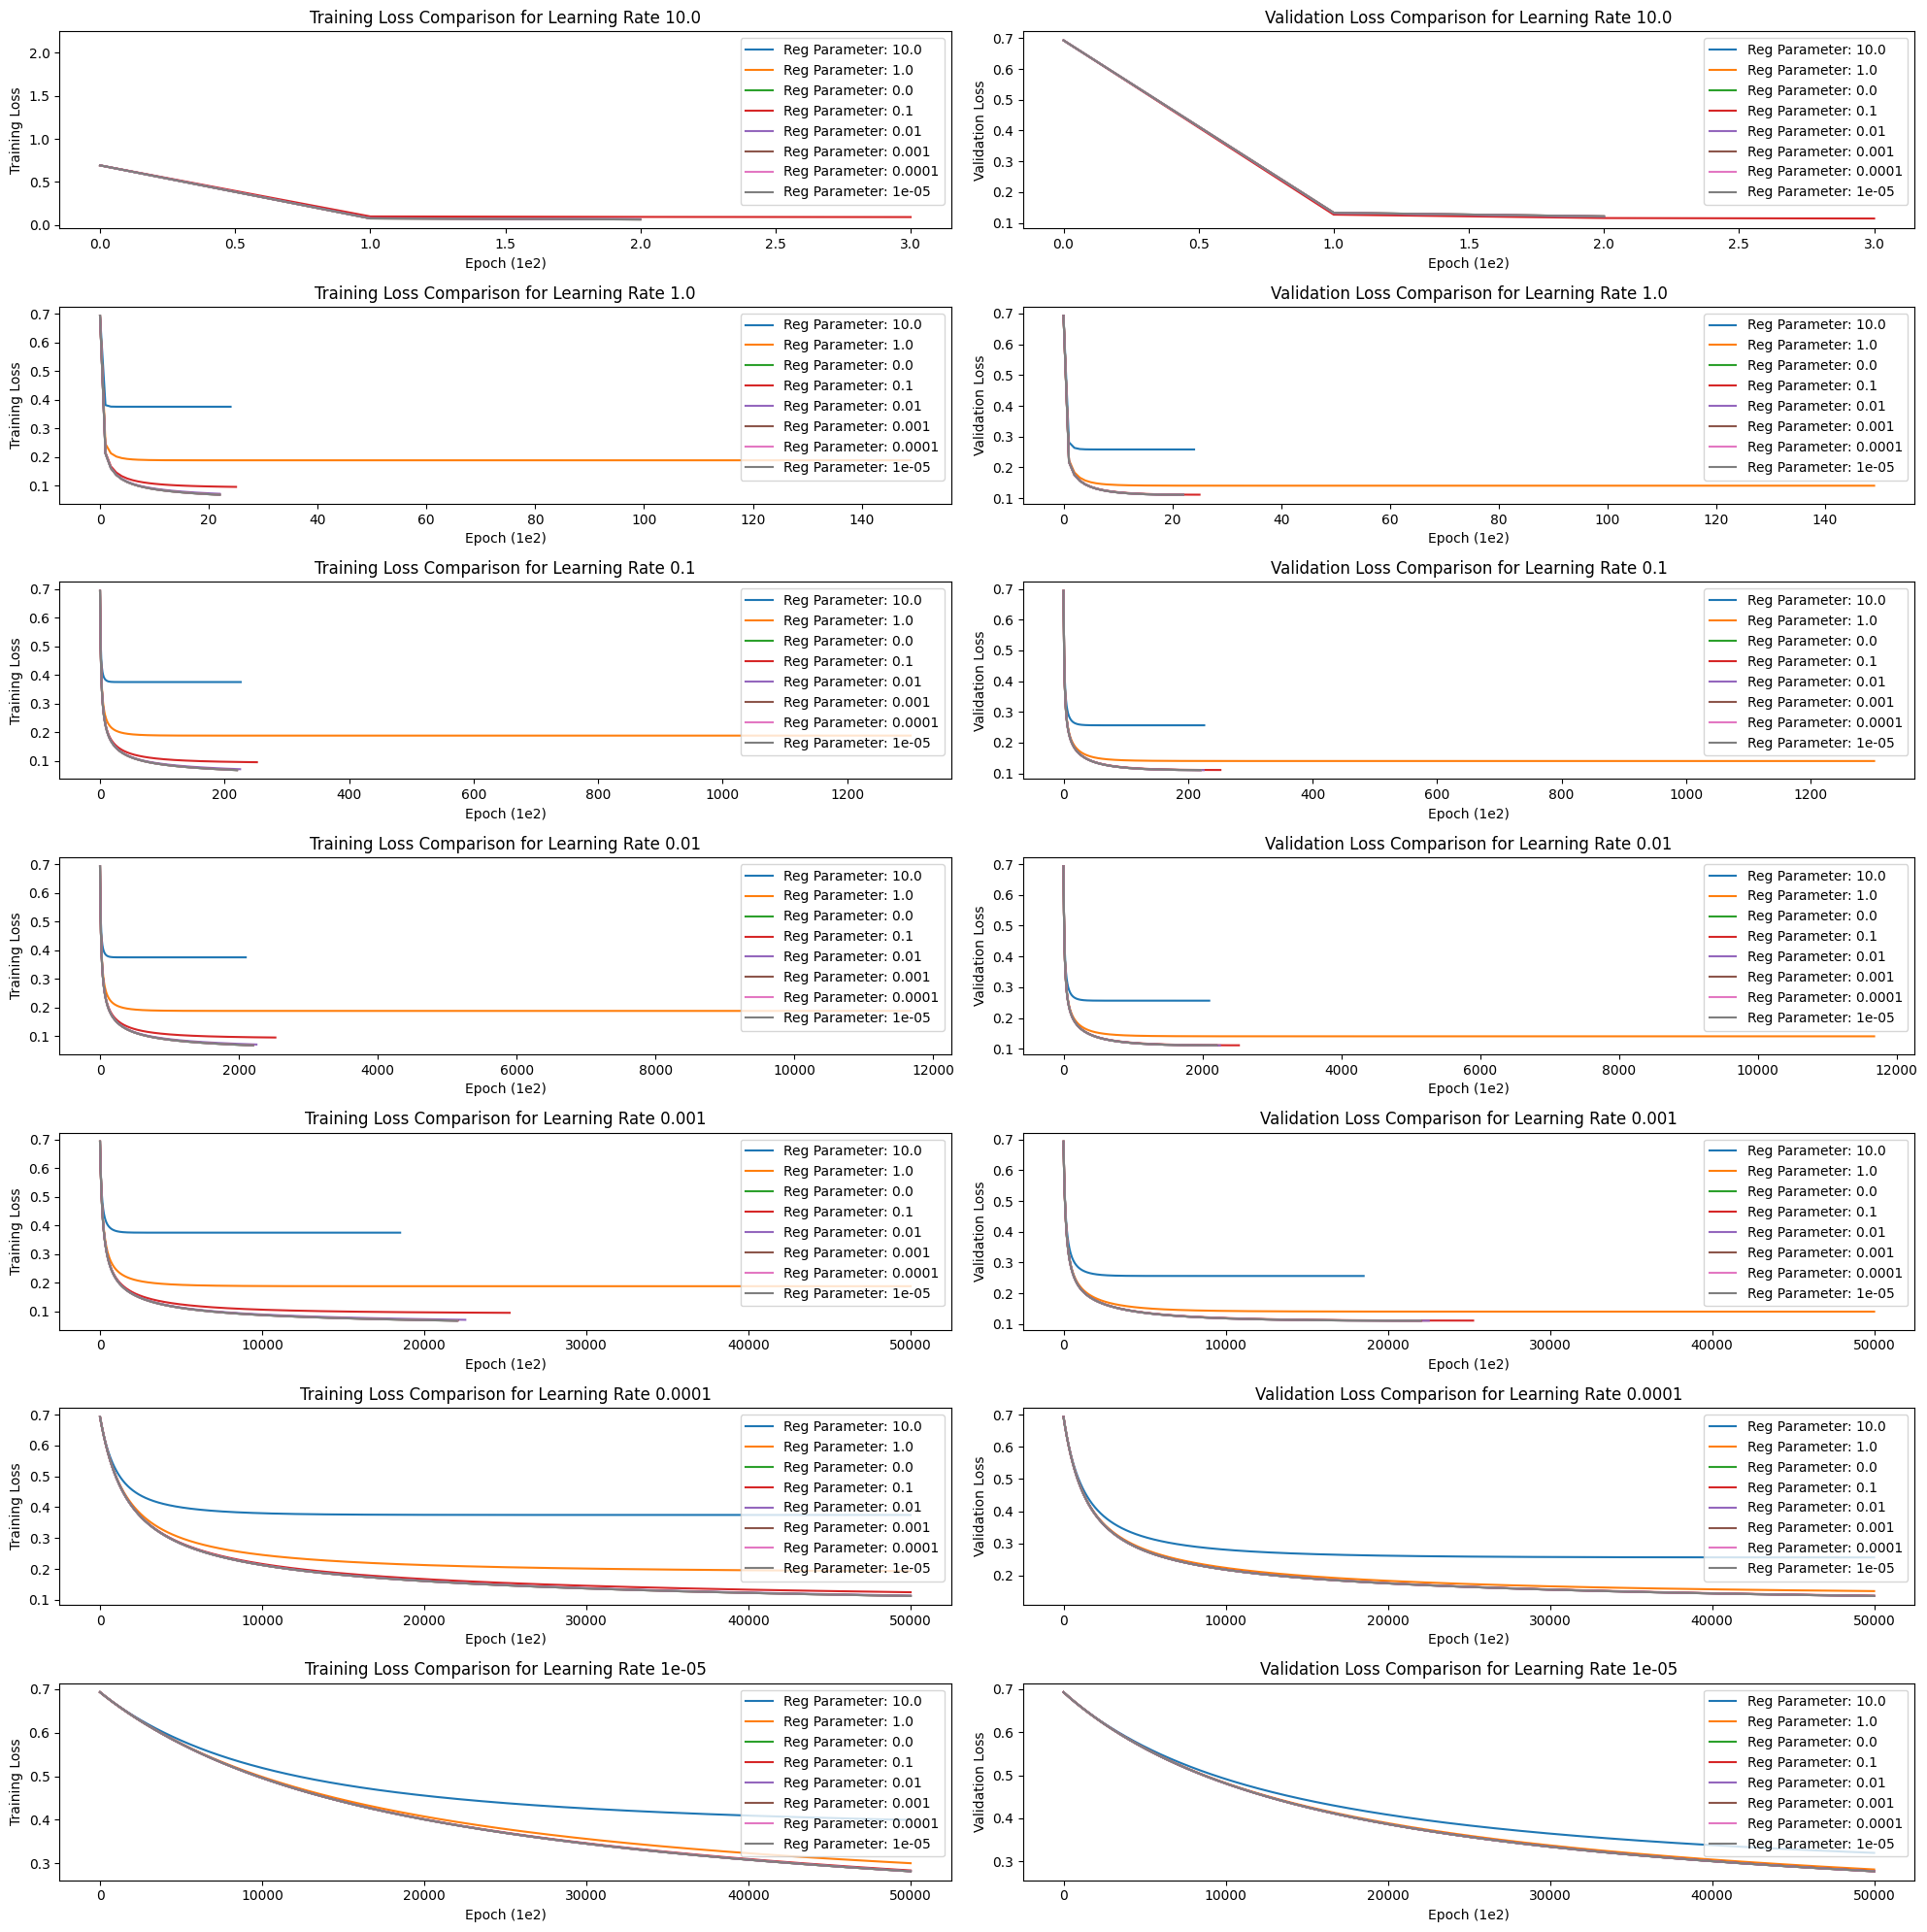

In [27]:
fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(20,20))
for params, loss in loss_by_param.items():
    alpha = float(params.split(',')[0].strip('('))
    lamda = float(params.split(',')[-1].strip(')').strip())
    if 10 == alpha:
        i = 0
    elif 1 == alpha:
        i = 1
    elif 0.1 == alpha:
        i = 2
    elif 0.01 == alpha:
        i = 3
    elif 0.001 == alpha:
        i = 4
    elif 0.0001 == alpha:
        i = 5
    else:
        i = 6
    ax[i][0].plot(loss[0], label=f'Reg Parameter: {lamda}')
    ax[i][0].set_title(f"Training Loss Comparison for Learning Rate {alpha}")
    ax[i][0].set_xlabel('Epoch (1e2)')
    ax[i][0].set_ylabel('Training Loss')
    ax[i][0].legend()
    ax[i][1].plot(loss[1], label=f'Reg Parameter: {lamda}')
    ax[i][1].set_title(f"Validation Loss Comparison for Learning Rate {alpha}")
    ax[i][1].set_xlabel('Epoch (1e2)')
    ax[i][1].set_ylabel('Validation Loss')
    ax[i][1].legend()
fig.tight_layout()

#### Hyperparameter results
In general, model converges faster with a larger learning rate, but once we get to a learning rate of 1e-5, we don't reach the same levels of loss in the time allowed to train, so it makes sense that our optimal learning rate is one of the middle values. As far as regularization goes, this model benefits from regularization. The training loss is reported with regularization so it may be a little higher than validation loss, but we can consistently see that a regularization parameter of 10 is not usually beneficial. We chose hyperparameters based on validation accuracy first, then lowest validation loss in the event of a tie so it is interesting that our chosen regularization parameter often made it train the longest. 